# 26 Weekly DMOs -> Fatigue

In [9]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.pipeline import dmo_for_random_forest
from src.model import DMORandomForestRegressor
from src.evaluation import Evaluation

import torch

In [10]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
    "total_worn_during_waking_h",
]

In [11]:
static_features = [
    "weight",
    "height",
    "EDFSCR1L"
]

In [20]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    filtered=True,
    #static_features=static_features,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [21]:
print(dmo_data.shape)

torch.Size([593, 5, 7, 26])


In [14]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [22]:
print(dmo_data.shape)

torch.Size([593, 5, 7, 26])


In [23]:
# remove patients that don't have a full dataset
patient_indexs = []
patients, visits, features, days = dmo_data.shape
for p in range(patients):
    all_visits = True
    for v in range(visits):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [24]:
print(dmo_data.shape)
print(dmo_labels.shape)
# flatten to weekly summaries (this keeps patients consistant over the testing)
#dmo_data = dmo_data.mean(axis=2)

torch.Size([38, 5, 7, 26])
torch.Size([38, 5, 1])


In [36]:
transforms = (None, None)
train, test = dmo_for_random_forest(dmo_data, dmo_labels, transforms)

train_input, train_label = train
test_input, test_label = test

In [37]:
patient, visit, features = train_input.shape
train_input = train_input.reshape(patient * visit, features)
train_label = train_label.reshape(patient * visit)

patient, visit, features = test_input.shape
test_input = test_input.reshape(patient * visit, features)
test_label = test_label.reshape(patient * visit)

In [38]:
rf_model = DMORandomForestRegressor(n_trees=500)

rf_model.train(train_input, train_label)


{'accuracy': 0.00392156862745098, 'Mean Squared Error': 482.8459777832031, 'Mean Absolute Error': 18.632917404174805, 'R^2': -1.0737039349469661}


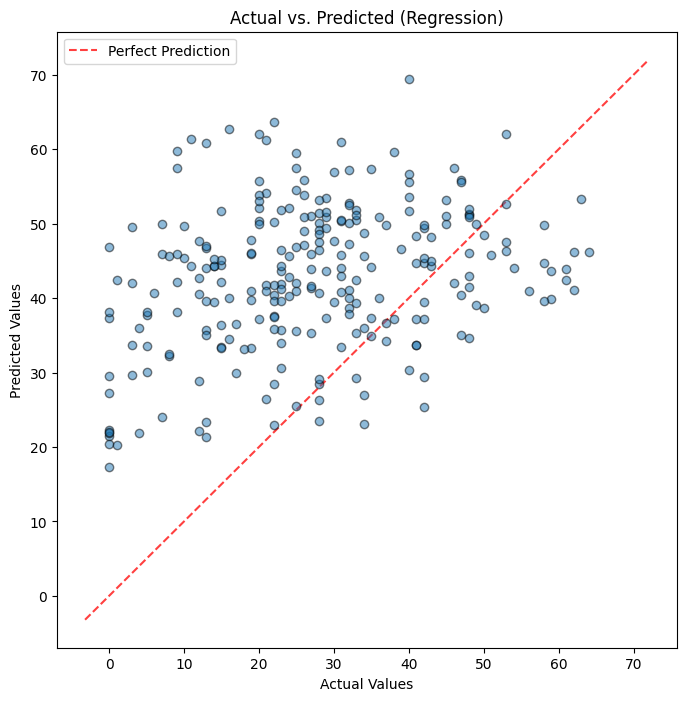

In [39]:
prediction = torch.tensor(rf_model.predict(test_input))
actual = test_label
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()